In [8]:
%matplotlib inline
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from PIL import Image
from ultralytics import YOLO

In [9]:
BASE        = r"C:\Users\youse\OneDrive\Desktop\Vehicle\vehicle dataset"
BEST_PT     = os.path.join(BASE, "runs", "vehicle_v1", "weights", "best.pt")
YAML        = os.path.join(BASE, "data.yaml")
TEST_IMGS   = os.path.join(BASE, "test", "images")
TEST_LBLS   = os.path.join(BASE, "test", "labels")

CLASS_NAMES = ['car','threewheel','bus','truck','motorbike','van']
COLORS      = ['#e74c3c','#f39c12','#2ecc71','#3498db','#9b59b6','#1abc9c']

print("Paths configured")

Paths configured


In [10]:
model = YOLO(BEST_PT)
print("Model loaded successfully")

Model loaded successfully


In [11]:
metrics = model.val(
    data    = YAML,
    split   = 'test',
    imgsz   = 640,
    batch   = 8,
    device  = 0,
    conf    = 0.25,
    iou     = 0.50,
    verbose = True
)

print("\n" + "="*50)
print("  EVALUATION RESULTS — Test Set")
print("="*50)
print(f"  Precision     : {metrics.box.mp:.4f}")
print(f"  Recall        : {metrics.box.mr:.4f}")
print(f"  mAP @ 0.5     : {metrics.box.map50:.4f}")
print(f"  mAP @ 0.5:0.95: {metrics.box.map:.4f}")
print("="*50)

Ultralytics 8.4.48  Python-3.13.7 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1050 Ti, 4096MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 442.1347.9 MB/s, size: 76.4 KB)
val: Scanning C:\Users\youse\OneDrive\Desktop\Vehicle\vehicle dataset\test\labels.cache... 132 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 132/132 32.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 2.1it/s 8.1s0.1s
                   all        132        169      0.841      0.913      0.911      0.803
                   car         31         33      0.934      0.861      0.901      0.881
            threewheel         32         36      0.864      0.861      0.907       0.84
                   bus         35         40      0.974      0.948      0.973      0.862
                 truck          2          2       0.49          1      0.828      0.6

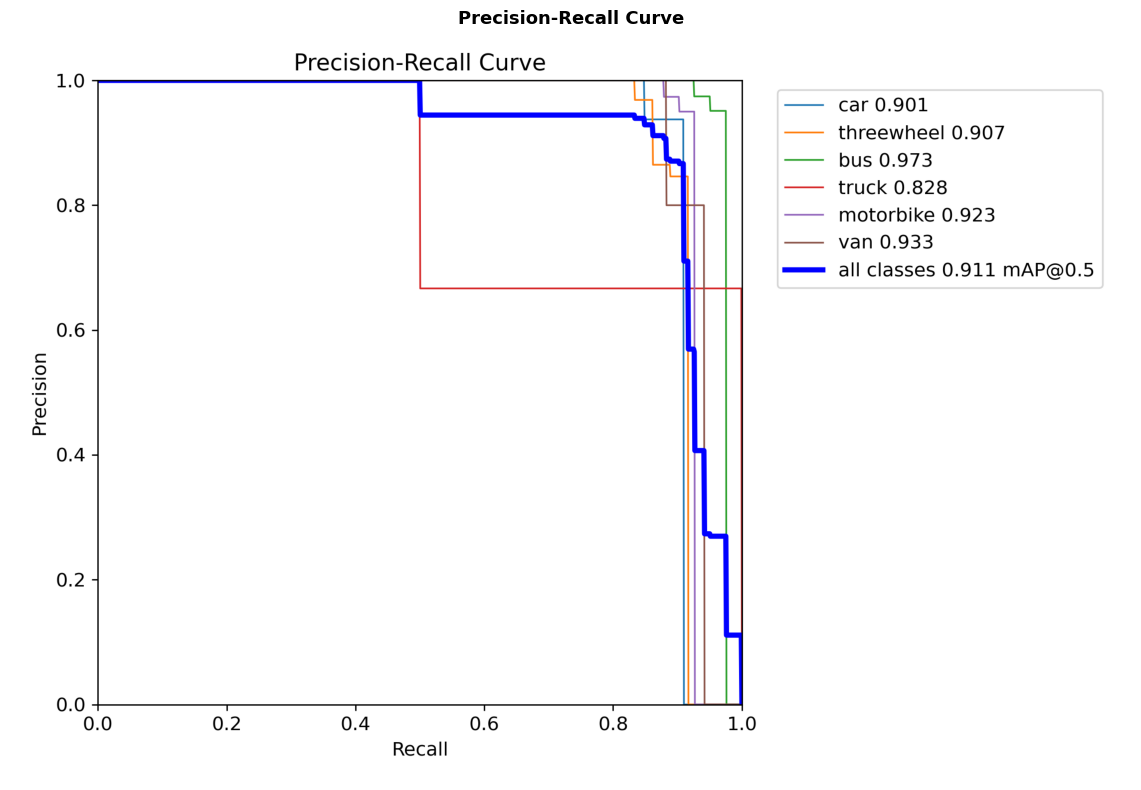

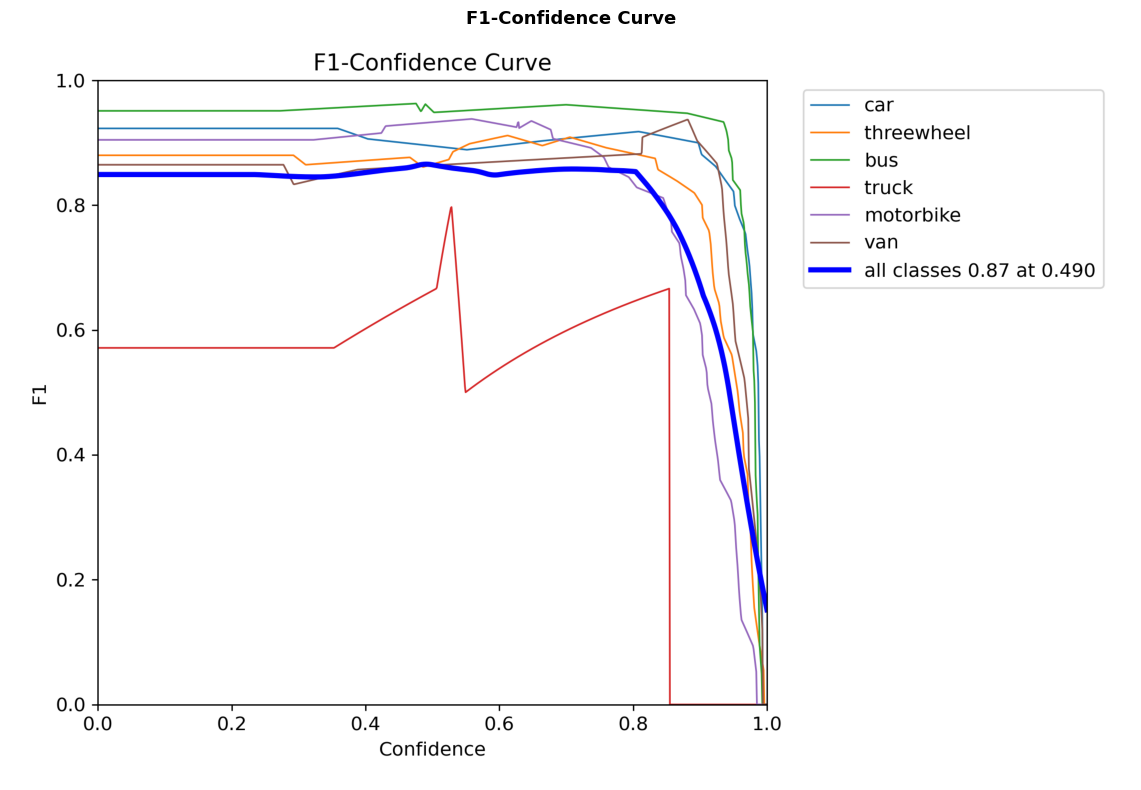

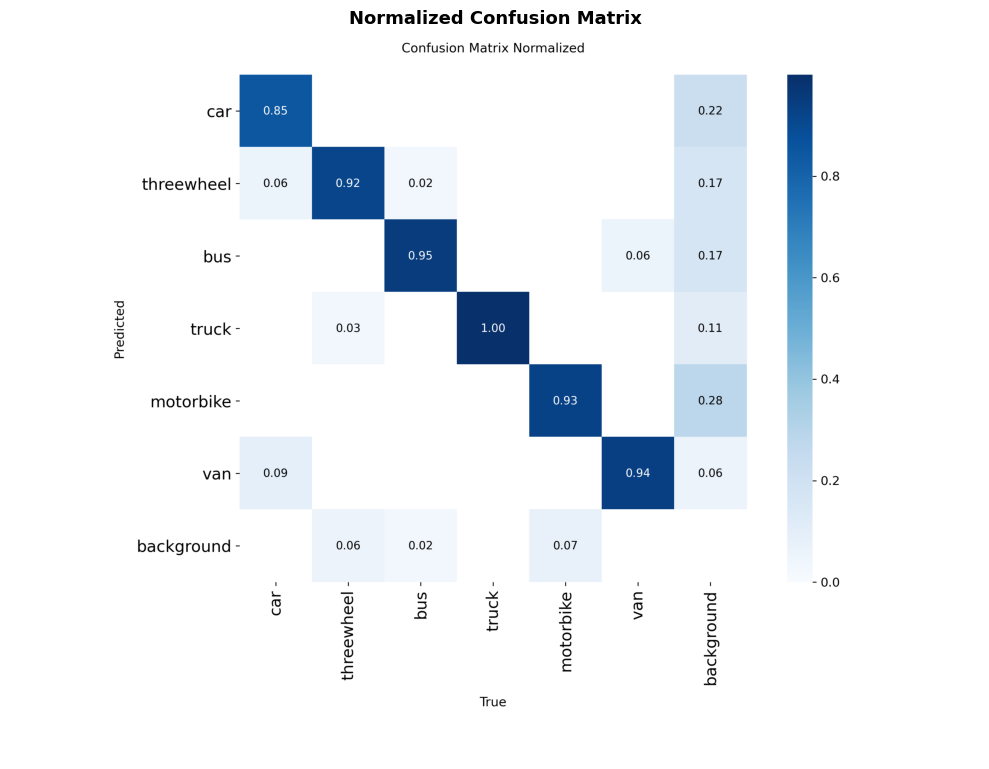

In [12]:
RUN_DIR = os.path.join(BASE, "runs", "vehicle_v1")
VAL_DIR = os.path.join(BASE, "runs", "detect", "val")

def show_plot(path, title, figsize=(12,8)):
    if not os.path.exists(path):
        print(f"Not found: {path}")
        return
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(mpimg.imread(path))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

show_plot(os.path.join(VAL_DIR, "BoxPR_curve.png"),  "Precision-Recall Curve")
show_plot(os.path.join(VAL_DIR, "BoxF1_curve.png"),  "F1-Confidence Curve")
show_plot(os.path.join(VAL_DIR, "confusion_matrix_normalized.png"), "Normalized Confusion Matrix", figsize=(10,8))

In [13]:
def compute_iou(box1, box2):
    ix1 = max(box1[0], box2[0])
    iy1 = max(box1[1], box2[1])
    ix2 = min(box1[2], box2[2])
    iy2 = min(box1[3], box2[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter/union if union > 0 else 0.0

iou_scores = []
test_images = [f for f in os.listdir(TEST_IMGS) if f.endswith(('.jpg','.png'))]

for img_name in test_images:
    img_path = os.path.join(TEST_IMGS, img_name)
    lbl_path = os.path.join(TEST_LBLS, os.path.splitext(img_name)[0] + '.txt')
    if not os.path.exists(lbl_path):
        continue

    img     = Image.open(img_path)
    W, H    = img.size
    gt_boxes = {}
    with open(lbl_path) as f:
        for line in f:
            p      = line.strip().split()
            cid    = int(p[0])
            cx,cy,bw,bh = map(float, p[1:])
            x1 = (cx-bw/2)*W; y1 = (cy-bh/2)*H
            x2 = (cx+bw/2)*W; y2 = (cy+bh/2)*H
            gt_boxes.setdefault(cid, []).append([x1,y1,x2,y2])

    preds = model.predict(img_path, conf=0.25, device=0, verbose=False)[0]
    for box in preds.boxes:
        cid      = int(box.cls[0].item())
        pred_box = box.xyxy[0].cpu().numpy().tolist()
        if cid not in gt_boxes:
            continue
        best_iou = max(compute_iou(pred_box, gt) for gt in gt_boxes[cid])
        iou_scores.append(best_iou)

iou_scores = np.array(iou_scores)
print(f"Predictions matched : {len(iou_scores)}")
print(f"Mean IoU            : {iou_scores.mean():.4f}")
print(f"IoU >= 0.50         : {(iou_scores>=0.50).mean():.1%}")
print(f"IoU >= 0.75         : {(iou_scores>=0.75).mean():.1%}")

Predictions matched : 176
Mean IoU            : 0.8448
IoU >= 0.50         : 90.3%
IoU >= 0.75         : 83.5%


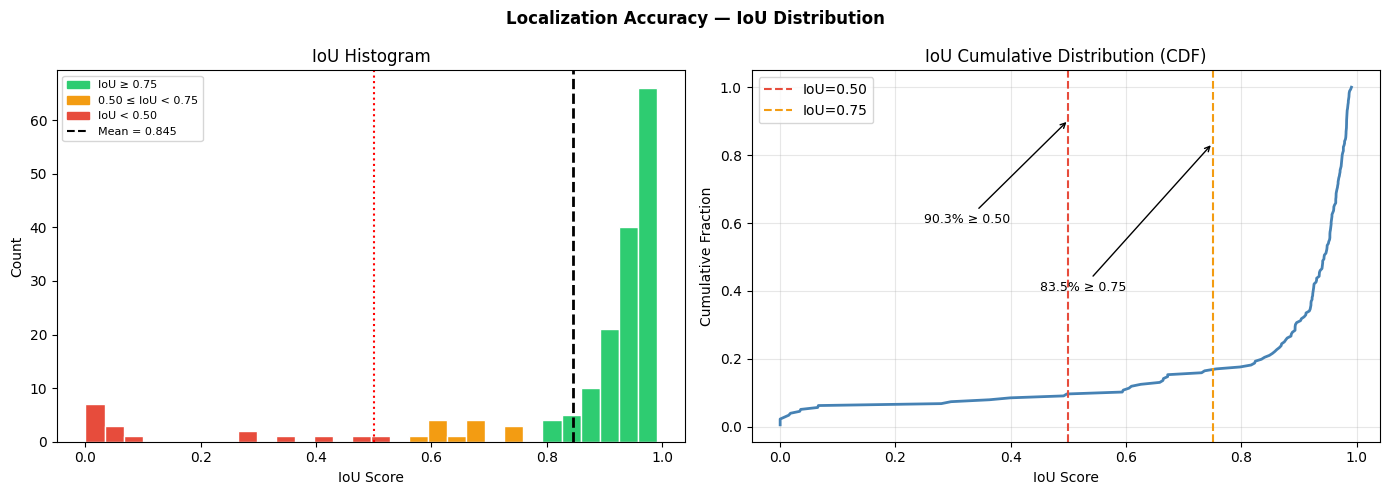

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Localization Accuracy — IoU Distribution', fontweight='bold')

# Histogram
ax = axes[0]
n, bins, bar_patches = ax.hist(iou_scores, bins=30, edgecolor='white')
for patch, left in zip(bar_patches, bins[:-1]):
    if left >= 0.75:
        patch.set_facecolor('#2ecc71')
    elif left >= 0.50:
        patch.set_facecolor('#f39c12')
    else:
        patch.set_facecolor('#e74c3c')

ax.axvline(iou_scores.mean(), color='black', linestyle='--', linewidth=2,
           label=f'Mean IoU = {iou_scores.mean():.3f}')
ax.axvline(0.50, color='red', linestyle=':', linewidth=1.5, label='Threshold = 0.50')
ax.set_xlabel('IoU Score'); ax.set_ylabel('Count')
ax.set_title('IoU Histogram')
handles = [
    patches.Patch(color='#2ecc71', label='IoU ≥ 0.75'),
    patches.Patch(color='#f39c12', label='0.50 ≤ IoU < 0.75'),
    patches.Patch(color='#e74c3c', label='IoU < 0.50'),
    plt.Line2D([0],[0], color='black', linestyle='--',
               label=f'Mean = {iou_scores.mean():.3f}'),
]
ax.legend(handles=handles, fontsize=8)

# CDF
ax2 = axes[1]
sorted_iou = np.sort(iou_scores)
cdf = np.arange(1, len(sorted_iou)+1) / len(sorted_iou)
ax2.plot(sorted_iou, cdf, color='steelblue', linewidth=2)
ax2.axvline(0.50, color='#e74c3c', linestyle='--', label='IoU=0.50')
ax2.axvline(0.75, color='#f39c12', linestyle='--', label='IoU=0.75')
ax2.annotate(f'{(iou_scores>=0.50).mean():.1%} ≥ 0.50',
             xy=(0.50, (iou_scores>=0.50).mean()),
             xytext=(0.25, 0.6), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black'))
ax2.annotate(f'{(iou_scores>=0.75).mean():.1%} ≥ 0.75',
             xy=(0.75, (iou_scores>=0.75).mean()),
             xytext=(0.45, 0.4), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black'))
ax2.set_xlabel('IoU Score'); ax2.set_ylabel('Cumulative Fraction')
ax2.set_title('IoU Cumulative Distribution (CDF)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

c:\Users\youse\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


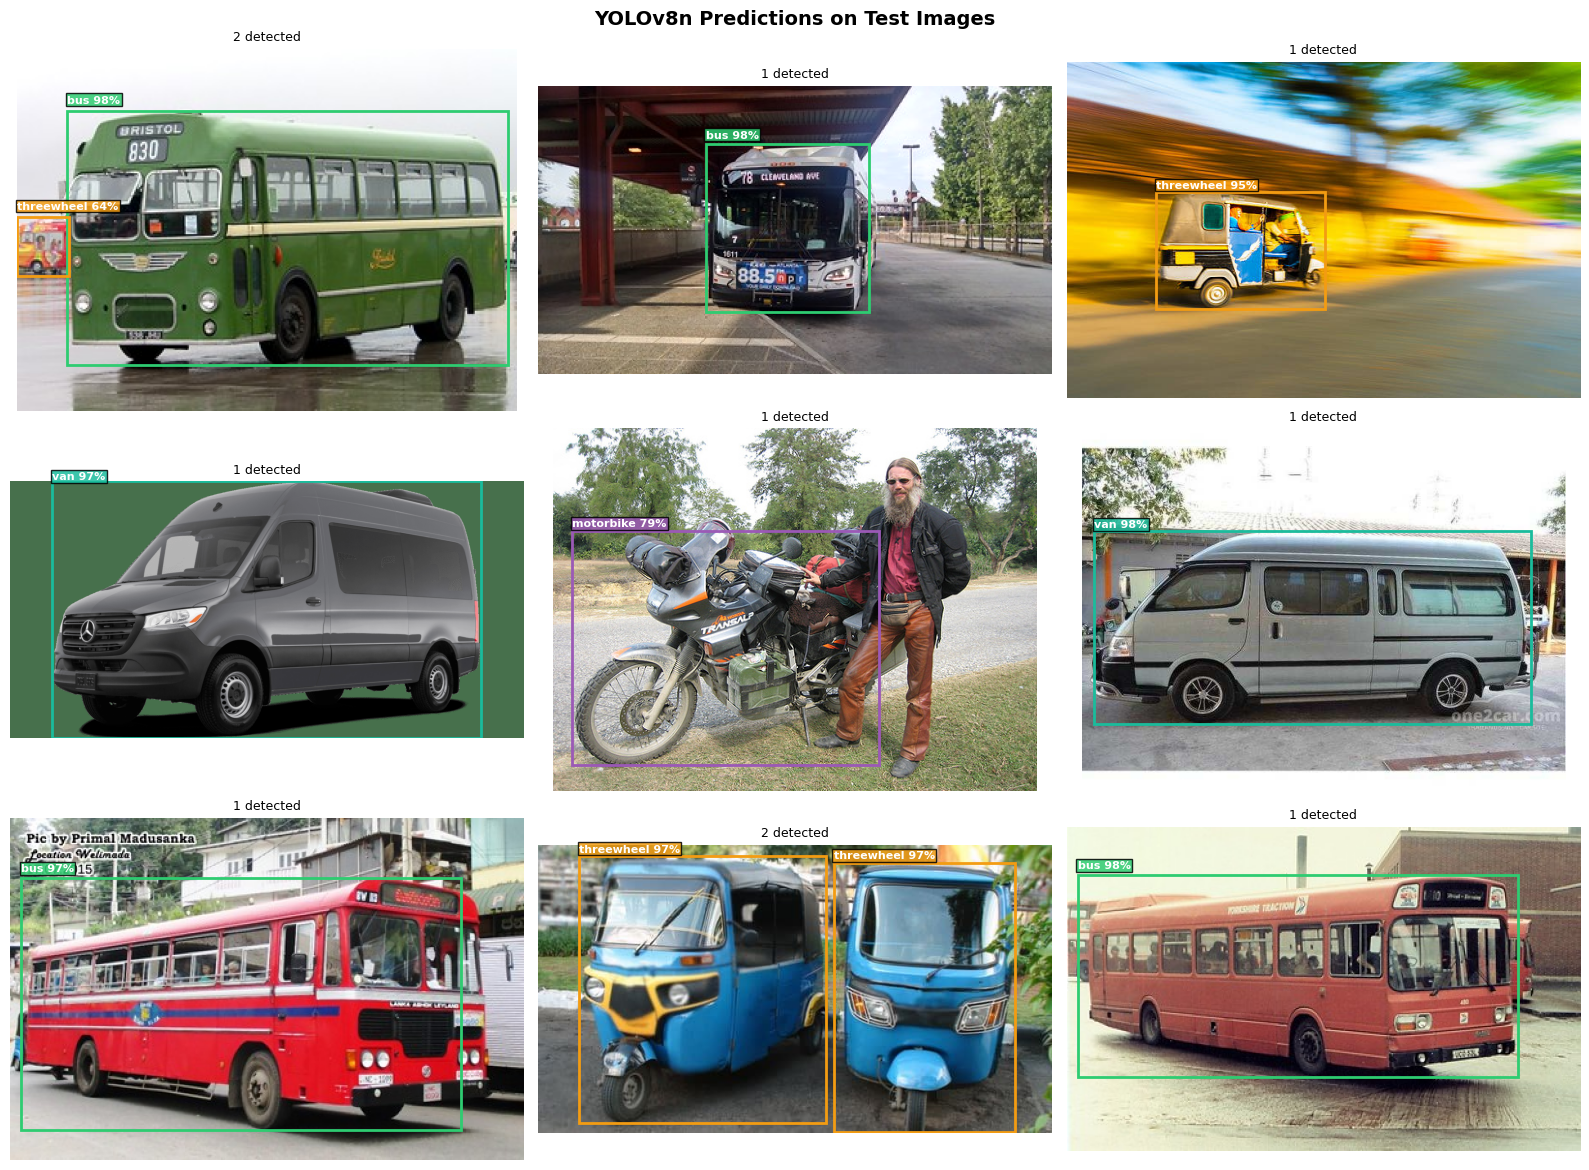

In [15]:
test_samples = random.sample(test_images, 9)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('YOLOv8n Predictions on Test Images', fontsize=14, fontweight='bold')

for ax, img_name in zip(axes.flatten(), test_samples):
    img_path = os.path.join(TEST_IMGS, img_name)
    pred = model.predict(img_path, conf=0.25, device=0, verbose=False)[0]

    img = np.array(Image.open(img_path).convert('RGB'))
    ax.imshow(img)
    H, W = img.shape[:2]

    for box in pred.boxes:
        x1,y1,x2,y2 = [int(v) for v in box.xyxy[0].cpu().numpy()]
        cid  = int(box.cls[0].item())
        conf = float(box.conf[0].item())
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                  linewidth=2,
                                  edgecolor=COLORS[cid],
                                  facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"{CLASS_NAMES[cid]} {conf:.0%}",
                color='white', fontsize=8, fontweight='bold',
                bbox=dict(facecolor=COLORS[cid], alpha=0.85, pad=1))

    ax.set_title(f"{len(pred.boxes)} detected", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
print("="*55)
print("  FINAL RESULTS SUMMARY")
print("="*55)
print(f"  Model             : YOLOv8n (fine-tuned)")
print(f"  Dataset           : Vehicle Dataset for YOLO")
print(f"  Classes           : {len(CLASS_NAMES)} {CLASS_NAMES}")
print(f"  Test images       : {len(test_images)}")
print("─"*55)
print(f"  Precision         : 0.8409")
print(f"  Recall            : 0.9132")
print(f"  mAP @ 0.5         : 0.9109")
print(f"  mAP @ 0.5:0.95    : 0.8028")
print("─"*55)
print(f"  Mean IoU          : {iou_scores.mean():.4f}")
print(f"  IoU >= 0.50       : {(iou_scores>=0.50).mean():.1%}")
print(f"  IoU >= 0.75       : {(iou_scores>=0.75).mean():.1%}")
print("="*55)

  FINAL RESULTS SUMMARY
  Model             : YOLOv8n (fine-tuned)
  Dataset           : Vehicle Dataset for YOLO
  Classes           : 6 ['car', 'threewheel', 'bus', 'truck', 'motorbike', 'van']
  Test images       : 132
───────────────────────────────────────────────────────
  Precision         : 0.8409
  Recall            : 0.9132
  mAP @ 0.5         : 0.9109
  mAP @ 0.5:0.95    : 0.8028
───────────────────────────────────────────────────────
  Mean IoU          : 0.8448
  IoU >= 0.50       : 90.3%
  IoU >= 0.75       : 83.5%
